In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Download test data
X_test = load_npz('data/processed/X_test_tfidf.npz')
y_test = np.load('data/processed/y_test.npy')
y_train = np.load('data/processed/y_train.npy')

print(f"Test data shape: {X_test.shape}")
print(f"Distribution in test: REAL={sum(y_test==0)}, FAKE={sum(y_test==1)}")

# Download best model
with open('models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)
print("Model saved from 'models/'")

# Download metadata from model (if have)
try:
    with open('models/best_model_info.pkl', 'rb') as f:
        model_info = pickle.load(f)
    print("Metadata loaded")
    print(f"Model: {model_info['name']}")
    print(f"F1-score with train: {model_info['f1_score']:.4f}")
except:
    print("Metadata no found")    


Test data shape: (8980, 5000)
Distribution in test: REAL=4696, FAKE=4284
Model saved from 'models/'
Metadata loaded
Model: XGBoost
F1-score with train: 0.9981


Metrics on the test data: 
Accuracy: 0.5228
Precision: 0.428571
Recall: 0.0007
F1-score: 0.0014
ROC-AUC: 0.4999
RP-AUC: 0.4568

Classification report:
              precision    recall  f1-score   support

        FAKE       0.52      1.00      0.69      4696
        REAL       0.43      0.00      0.00      4284

    accuracy                           0.52      8980
   macro avg       0.48      0.50      0.34      8980
weighted avg       0.48      0.52      0.36      8980



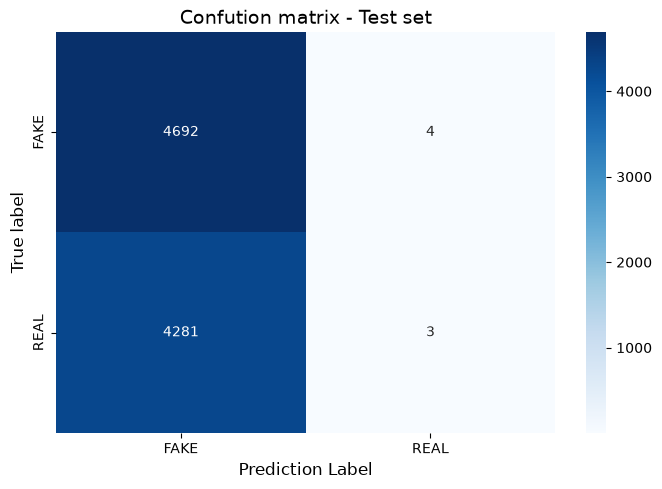

Matrix saved in 'models/'


In [3]:
# Base metrics with test dataset
# Predictions
y_pred = model.predict(X_test)

# Checking if predict_proba exist
if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
else:
    y_pred_proba = None
    print("Model not supported predict_proba, ROC-AUC and RP-AUC not unavailable")
    
# Metrics 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Metrics on the test data: ")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

if y_pred_proba is not None:
    roc_auc = roc_auc_score(y_test, y_pred)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"RP-AUC: {avg_precision:.4f}")
    
# Detailed report
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))

# Confution matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["FAKE", "REAL"],
            yticklabels={'FAKE', "REAL"})
plt.title('Confution matrix - Test set', fontsize=14)
plt.ylabel('True label', fontsize=12)
plt.xlabel('Prediction Label', fontsize=12)
plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=300)
plt.show()
print("Matrix saved in 'models/'")


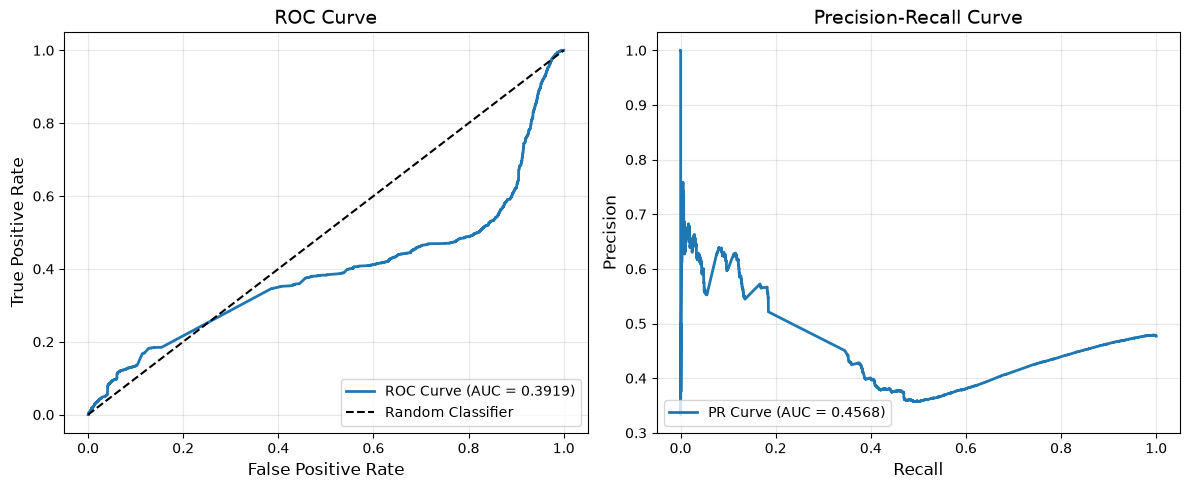

ROC and PR curves saved in 'models/'


In [4]:
# ROC-AUC and PR-ROC curves
if y_pred_proba is not None:
    # ROC curve
    fpr, tpr, thresholds  = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    # PR curve (Precision-Recall)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    plt.subplot(1, 2, 2)
    plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {avg_precision:.4f})', linewidth=2)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=14)
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('models/roc_pr_curves.png', dpi=300)
    plt.show()   
    print("ROC and PR curves saved in 'models/'")
else:
    print("Model no support predict_proba, skip ROC and PR curves")


Perform 5-fold cross validation

Cross validation results:
Fold 1: 0.9975
Fold 2: 0.9956
Fold 3: 0.9974
Fold 4: 0.9978
Fold 5: 0.9965

Mean F1-score: 0.9970 +- 0.0008


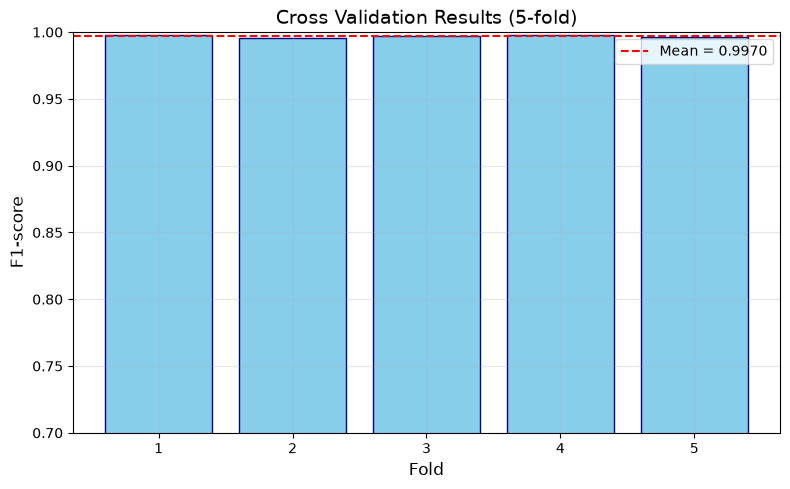

Cross validation results saved in 'models/'


In [5]:
# Cross validation
# Download train data for cross validation
X_train = load_npz('data/processed/X_train_tfidf.npz')

# Create scorer for F1
f1_scorer = make_scorer(f1_score)

# Stratified cross validation (preserves class proportions)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross validation
print("Perform 5-fold cross validation")
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=f1_scorer)

print(f"\nCross validation results:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"\nMean F1-score: {cv_scores.mean():.4f} +- {cv_scores.std():.4f}")

# Visualize cross validation results
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='skyblue', edgecolor='navy')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f"Mean = {cv_scores.mean():.4f}")
plt.xlabel("Fold", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.title('Cross Validation Results (5-fold)', fontsize=14)
plt.ylim([0.7, 1.0])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('models/cv_results.png', dpi=300)
plt.show()
print("Cross validation results saved in 'models/'")


In [14]:
# Out-of-source validation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import pickle

try:
    # Load data
    fake_df = pd.read_csv('database/Fake.csv')
    true_df = pd.read_csv('database/True.csv')

    # Add label
    fake_df['label'] = 0  # FAKE
    true_df['label'] = 1  # REAL
    
    # Add source
    fake_df['source'] = 'FAKE'
    true_df['source'] = 'REAL'
    
    # Combine
    all_data = pd.concat([fake_df, true_df], ignore_index=True)
    
    # Check text column
    if 'text' in all_data.columns:
        text_col = 'text'
    elif 'title' in all_data.columns:
        text_col = 'title'
    else:
        text_col = all_data.columns[0]
        
    print(f"Loaded {len(all_data)} news:")
    print(f"  FAKE: {len(fake_df)}")
    print(f"  REAL: {len(true_df)}")
    
    # Load vectorizer
    with open('models/tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    
    # Transform all data
    X_all = vectorizer.transform(all_data[text_col].fillna(''))
    y_all = all_data['label'].values
    sources = all_data['source'].values
    
    print(f"\nSources: {np.unique(sources)}")
    print(f"Classes in data: {np.unique(y_all)}")
    
    # Method 1: Train on mixed data, test on each source separately
    print("METHOD 1: Train on mixed data, test on each source")
    
    # Split mixed data (80% train, 20% validation)
    X_train_mixed, X_val, y_train_mixed, y_val = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )
    
    print(f"\nMixed training set: {X_train_mixed.shape[0]} samples")
    print(f"  REAL: {sum(y_train_mixed==1)}, FAKE: {sum(y_train_mixed==0)}")
    
    # Train model on mixed data
    mixed_model = LogisticRegression(max_iter=1000, random_state=42)
    mixed_model.fit(X_train_mixed, y_train_mixed)
    
    # Test on each source
    for source in ['FAKE', 'REAL']:
        source_idx = sources == source
        y_pred_source = mixed_model.predict(X_all[source_idx])
        score_source = f1_score(y_all[source_idx], y_pred_source)
        print(f"\nTest on {source} data ({sum(source_idx)} samples):")
        print(f"  F1-Score: {score_source:.4f}")
    

    # Method 2: Cross-source validation (train on one source, test on another)
    print("METHOD 2: Cross-source validation")
    
    # Check if each source has both classes
    for source in ['FAKE', 'REAL']:
        source_idx = sources == source
        unique_classes = np.unique(y_all[source_idx])
        print(f"\n{source} source classes: {unique_classes}")
        
        if len(unique_classes) < 2:
            print(f"{source} source has only one class! Cannot train on it alone.")
            print("Skipping training on this source.")
            continue
        
        # If source has both classes, we can train on it
        train_idx = sources == source
        test_idx = sources != source  # Test on all other sources
        
        X_train_cv = X_all[train_idx]
        y_train_cv = y_all[train_idx]
        X_test_cv = X_all[test_idx]
        y_test_cv = y_all[test_idx]
        
        print(f"\nTrain on {source}, test on other sources:")
        print(f"  Train: {X_train_cv.shape[0]} samples")
        print(f"  Test: {X_test_cv.shape[0]} samples")
        
        model_cv = LogisticRegression(max_iter=1000, random_state=42)
        model_cv.fit(X_train_cv, y_train_cv)
        y_pred_cv = model_cv.predict(X_test_cv)
        score_cv = f1_score(y_test_cv, y_pred_cv)
        print(f"  F1-Score: {score_cv:.4f}")
    
except FileNotFoundError as e:
    print(f"File not found: {e}")
    print("   Skipping out-of-source validation")
except Exception as e:
    print(f"Error during out-of-source validation: {e}")
    import traceback
    traceback.print_exc()

Loaded 44898 news:
  FAKE: 23481
  REAL: 21417

Sources: ['FAKE' 'REAL']
Classes in data: [0 1]
METHOD 1: Train on mixed data, test on each source

Mixed training set: 35918 samples
  REAL: 17133, FAKE: 18785

Test on FAKE data (23481 samples):
  F1-Score: 0.0000

Test on REAL data (21417 samples):
  F1-Score: 0.9979
METHOD 2: Cross-source validation

FAKE source classes: [0]
FAKE source has only one class! Cannot train on it alone.
Skipping training on this source.

REAL source classes: [1]
REAL source has only one class! Cannot train on it alone.
Skipping training on this source.
